In [1]:
# Cell 1: Imports and configuration

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import rasterio
import cv2

BASE = Path("/Volumes/Utkash SSD/SIH26143")

CHECKPOINT_PATH = BASE / "best_oil_spill_unet.pth"

DEVICE = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

IMAGE_SIZE = 256
INFERENCE_STRIDE = 128
PREDICTION_THRESHOLD = 0.5

print("Device:", DEVICE)
print("Dataset:", BASE)
print("Checkpoint:", CHECKPOINT_PATH)
print("Checkpoint exists:", CHECKPOINT_PATH.exists())

Device: mps
Dataset: /Volumes/Utkash SSD/SIH26143
Checkpoint: /Volumes/Utkash SSD/SIH26143/best_oil_spill_unet.pth
Checkpoint exists: True


In [2]:
# Cell 2: U-Net architecture

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=2, out_channels=1):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(kernel_size=2)

        self.bottleneck = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(
            64, 32, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(64, 32)

        self.output = nn.Conv2d(
            32, out_channels, kernel_size=1
        )

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.output(d1)


model = UNet(
    in_channels=2,
    out_channels=1
).to(DEVICE)

print("Model initialized successfully.")

Model initialized successfully.


In [3]:
# Cell 3: Load trained checkpoint

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Checkpoint loaded successfully.")
print("Saved epoch:", checkpoint["epoch"])
print("Saved validation Dice:", checkpoint["val_dice"])
print("Model ready for inference.")

Checkpoint loaded successfully.
Saved epoch: 10
Saved validation Dice: 0.6649814770621787
Model ready for inference.


In [4]:
# Cell 4: Load and inspect a SAR image

OIL_DIR = BASE / "Oil"

sample_image_path = sorted(OIL_DIR.glob("*.tif"))[0]

with rasterio.open(sample_image_path) as src:
    sample_image = src.read().astype(np.float32)
    sample_transform = src.transform
    sample_crs = src.crs
    sample_bounds = src.bounds

print("Image:", sample_image_path.name)
print("Shape:", sample_image.shape)
print("Dtype:", sample_image.dtype)
print("CRS:", sample_crs)
print("Bounds:", sample_bounds)

for band in range(sample_image.shape[0]):
    print(
        f"Band {band + 1}: "
        f"min={sample_image[band].min():.4f}, "
        f"max={sample_image[band].max():.4f}, "
        f"mean={sample_image[band].mean():.4f}"
    )

Image: 00000.tif
Shape: (2, 2048, 2048)
Dtype: float32
CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
Bounds: BoundingBox(left=3.9656639450910203, bottom=55.14999011252874, right=4.1496389152786985, top=55.33396508271642)
Band 1: min=-54.1210, max=-1.9930, mean=-34.2708
Band 2: min=-38.2463, max=5.5457, mean=-20.7845


ERROR 1: PROJ: internal_proj_identify: /opt/anaconda3/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 6 is expected. It comes from another PROJ installation.


In [5]:
# Cell 5: Preprocess SAR image

def preprocess_sar_image(image):
    image = image.copy().astype(np.float32)

    for band in range(image.shape[0]):
        low = np.percentile(image[band], 1)
        high = np.percentile(image[band], 99)

        image[band] = np.clip(
            (image[band] - low) / (high - low + 1e-6),
            0,
            1
        )

    return image


processed_image = preprocess_sar_image(sample_image)

print("Processed shape:", processed_image.shape)
print("Processed dtype:", processed_image.dtype)

for band in range(processed_image.shape[0]):
    print(
        f"Band {band + 1}: "
        f"min={processed_image[band].min():.4f}, "
        f"max={processed_image[band].max():.4f}, "
        f"mean={processed_image[band].mean():.4f}"
    )

Processed shape: (2, 2048, 2048)
Processed dtype: float32
Band 1: min=0.0000, max=1.0000, mean=0.6471
Band 2: min=0.0000, max=1.0000, mean=0.5342


In [6]:
# Cell 6: Full-image overlapping inference

def predict_full_image(model, image, patch_size=256, stride=128, device=DEVICE):
    channels, height, width = image.shape

    probability_sum = np.zeros(
        (height, width),
        dtype=np.float32
    )

    prediction_count = np.zeros(
        (height, width),
        dtype=np.float32
    )

    model.eval()

    with torch.no_grad():
        for y in range(0, height - patch_size + 1, stride):
            for x in range(0, width - patch_size + 1, stride):

                patch = image[
                    :,
                    y:y + patch_size,
                    x:x + patch_size
                ]

                tensor = torch.from_numpy(patch).float()
                tensor = tensor.unsqueeze(0).to(device)

                logits = model(tensor)
                probabilities = torch.sigmoid(logits)

                probabilities = (
                    probabilities[0, 0]
                    .cpu()
                    .numpy()
                )

                probability_sum[
                    y:y + patch_size,
                    x:x + patch_size
                ] += probabilities

                prediction_count[
                    y:y + patch_size,
                    x:x + patch_size
                ] += 1

    probability_map = (
        probability_sum /
        np.maximum(prediction_count, 1)
    )

    prediction_mask = (
        probability_map >= PREDICTION_THRESHOLD
    ).astype(np.uint8)

    return probability_map, prediction_mask


probability_map, prediction_mask = predict_full_image(
    model,
    processed_image,
    patch_size=IMAGE_SIZE,
    stride=INFERENCE_STRIDE
)

print("Probability map shape:", probability_map.shape)
print("Prediction mask shape:", prediction_mask.shape)
print("Predicted spill pixels:", prediction_mask.sum())
print(
    "Predicted spill coverage:",
    f"{prediction_mask.mean() * 100:.2f}%"
)

Probability map shape: (2048, 2048)
Prediction mask shape: (2048, 2048)
Predicted spill pixels: 20513
Predicted spill coverage: 0.49%


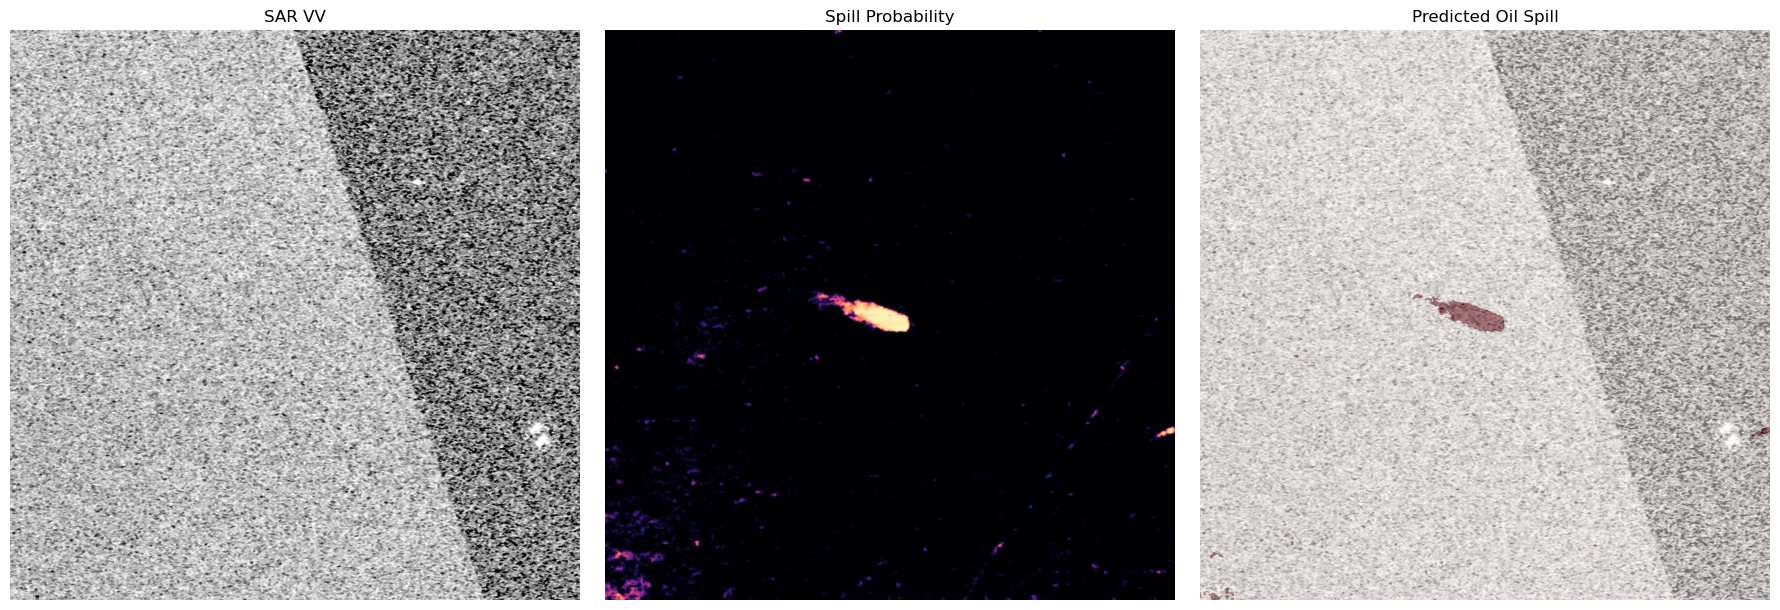

In [7]:
# Cell 7: Visualize full-image prediction

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(processed_image[0], cmap="gray")
axes[0].set_title("SAR VV")
axes[0].axis("off")

axes[1].imshow(probability_map, cmap="magma", vmin=0, vmax=1)
axes[1].set_title("Spill Probability")
axes[1].axis("off")

axes[2].imshow(processed_image[0], cmap="gray")
axes[2].imshow(
    prediction_mask,
    cmap="Reds",
    alpha=0.45
)
axes[2].set_title("Predicted Oil Spill")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Cell 8: Detect connected spill components

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    prediction_mask,
    connectivity=8
)

components = []

for label_id in range(1, num_labels):
    x = stats[label_id, cv2.CC_STAT_LEFT]
    y = stats[label_id, cv2.CC_STAT_TOP]
    width = stats[label_id, cv2.CC_STAT_WIDTH]
    height = stats[label_id, cv2.CC_STAT_HEIGHT]
    area = stats[label_id, cv2.CC_STAT_AREA]

    center_x, center_y = centroids[label_id]

    components.append({
        "label": label_id,
        "area_pixels": int(area),
        "x": int(x),
        "y": int(y),
        "width": int(width),
        "height": int(height),
        "centroid_x": float(center_x),
        "centroid_y": float(center_y)
    })

components.sort(
    key=lambda item: item["area_pixels"],
    reverse=True
)

print("Total detected components:", len(components))

print("\nLargest detected components:")

for component in components[:10]:
    print(
        f"Label {component['label']:3d} | "
        f"Area: {component['area_pixels']:6d} px | "
        f"BBox: "
        f"{component['width']:4d}x{component['height']:4d} | "
        f"Centroid: "
        f"({component['centroid_x']:.1f}, "
        f"{component['centroid_y']:.1f})"
    )

Total detected components: 58

Largest detected components:
Label   9 | Area:  16549 px | BBox:  288x 128 | Centroid: (972.9, 1025.2)
Label  21 | Area:   1012 px | BBox:   64x  35 | Centroid: (2019.8, 1443.5)
Label  50 | Area:    716 px | BBox:   50x  26 | Centroid: (52.9, 2036.1)
Label   7 | Area:    380 px | BBox:   34x  17 | Centroid: (783.0, 956.6)
Label  27 | Area:    335 px | BBox:   39x  24 | Centroid: (49.2, 1885.2)
Label  43 | Area:    323 px | BBox:   34x  31 | Centroid: (104.6, 2017.8)
Label  13 | Area:    146 px | BBox:   20x  12 | Centroid: (345.1, 1171.7)
Label  45 | Area:    138 px | BBox:   26x  16 | Centroid: (20.6, 2021.1)
Label  25 | Area:    120 px | BBox:   11x  15 | Centroid: (330.8, 1842.7)
Label  29 | Area:    102 px | BBox:   20x  12 | Centroid: (75.0, 1889.3)


In [9]:
# Cell 9: Filter small connected components

MIN_COMPONENT_AREA = 500

filtered_components = [
    component
    for component in components
    if component["area_pixels"] >= MIN_COMPONENT_AREA
]

print("Components before filtering:", len(components))
print("Components after filtering :", len(filtered_components))

print("\nFiltered components:")

for component in filtered_components:
    print(
        f"Label {component['label']:3d} | "
        f"Area: {component['area_pixels']:6d} px | "
        f"BBox: "
        f"{component['width']:4d}x{component['height']:4d} | "
        f"Centroid: "
        f"({component['centroid_x']:.1f}, "
        f"{component['centroid_y']:.1f})"
    )

Components before filtering: 58
Components after filtering : 3

Filtered components:
Label   9 | Area:  16549 px | BBox:  288x 128 | Centroid: (972.9, 1025.2)
Label  21 | Area:   1012 px | BBox:   64x  35 | Centroid: (2019.8, 1443.5)
Label  50 | Area:    716 px | BBox:   50x  26 | Centroid: (52.9, 2036.1)


In [10]:
# Cell 10: Analyze image-edge contact

height, width = prediction_mask.shape

for component in filtered_components:
    x = component["x"]
    y = component["y"]
    w = component["width"]
    h = component["height"]

    touches_left = x == 0
    touches_top = y == 0
    touches_right = (x + w) >= width
    touches_bottom = (y + h) >= height

    component["touches_edge"] = (
        touches_left
        or touches_top
        or touches_right
        or touches_bottom
    )

    component["edge_sides"] = []

    if touches_left:
        component["edge_sides"].append("left")

    if touches_top:
        component["edge_sides"].append("top")

    if touches_right:
        component["edge_sides"].append("right")

    if touches_bottom:
        component["edge_sides"].append("bottom")


print("Component analysis:\n")

for component in filtered_components:
    edge_status = (
        ", ".join(component["edge_sides"])
        if component["touches_edge"]
        else "none"
    )

    print(
        f"Label {component['label']:3d} | "
        f"Area: {component['area_pixels']:6d} px | "
        f"Edge contact: {edge_status}"
    )

Component analysis:

Label   9 | Area:  16549 px | Edge contact: none
Label  21 | Area:   1012 px | Edge contact: right
Label  50 | Area:    716 px | Edge contact: bottom


In [11]:
# Cell 11: Extract geometry of the primary spill candidate

primary_component = filtered_components[0]
primary_label = primary_component["label"]

primary_mask = (
    labels == primary_label
).astype(np.uint8)

contours, _ = cv2.findContours(
    primary_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

if contours:
    contour = max(contours, key=cv2.contourArea)

    area_pixels = cv2.contourArea(contour)
    perimeter_pixels = cv2.arcLength(contour, True)

    x, y, w, h = cv2.boundingRect(contour)

    aspect_ratio = w / h if h > 0 else 0

    print("Primary spill label:", primary_label)
    print("Contour area:", f"{area_pixels:.2f} px²")
    print("Pixel-mask area:", f"{primary_component['area_pixels']} px")
    print("Perimeter:", f"{perimeter_pixels:.2f} px")
    print("Bounding box:", f"{w} × {h} px")
    print("Aspect ratio:", f"{aspect_ratio:.2f}")
    print(
        "Centroid:",
        f"({primary_component['centroid_x']:.2f}, "
        f"{primary_component['centroid_y']:.2f})"
    )
else:
    print("No contour found.")

Primary spill label: 9
Contour area: 16211.00 px²
Pixel-mask area: 16549 px
Perimeter: 917.72 px
Bounding box: 288 × 128 px
Aspect ratio: 2.25
Centroid: (972.88, 1025.24)


In [12]:
# Cell 12: Convert spill centroid to geographic coordinates

centroid_x = primary_component["centroid_x"]
centroid_y = primary_component["centroid_y"]

longitude, latitude = rasterio.transform.xy(
    sample_transform,
    centroid_y,
    centroid_x,
    offset="center"
)

print("Spill centroid:")
print(f"  Latitude : {latitude:.6f}")
print(f"  Longitude: {longitude:.6f}")

Spill centroid:
  Latitude : 55.241822
  Longitude: 4.053104


In [13]:
# Cell 13: Convert spill bounding box to geographic coordinates

x = primary_component["x"]
y = primary_component["y"]
w = primary_component["width"]
h = primary_component["height"]

left, top = rasterio.transform.xy(
    sample_transform,
    y,
    x,
    offset="center"
)

right, bottom = rasterio.transform.xy(
    sample_transform,
    y + h - 1,
    x + w - 1,
    offset="center"
)

geo_left = min(left, right)
geo_right = max(left, right)
geo_bottom = min(top, bottom)
geo_top = max(top, bottom)

print("Spill geographic bounding box:")
print(f"  West  : {geo_left:.6f}")
print(f"  South : {geo_bottom:.6f}")
print(f"  East  : {geo_right:.6f}")
print(f"  North : {geo_top:.6f}")

Spill geographic bounding box:
  West  : 4.038203
  South : 55.236543
  East  : 4.063985
  North : 55.247951


In [14]:
# Cell 14: Estimate spill footprint area in km²

pixel_width_deg = abs(sample_transform.a)
pixel_height_deg = abs(sample_transform.e)

mean_latitude = latitude

km_per_degree_lat = 111.32
km_per_degree_lon = 111.32 * np.cos(
    np.radians(mean_latitude)
)

pixel_width_km = pixel_width_deg * km_per_degree_lon
pixel_height_km = pixel_height_deg * km_per_degree_lat

spill_area_km2 = (
    primary_component["area_pixels"]
    * pixel_width_km
    * pixel_height_km
)

print("Approximate spill footprint:")
print(f"  Pixel width  : {pixel_width_km:.4f} km")
print(f"  Pixel height : {pixel_height_km:.4f} km")
print(f"  Area         : {spill_area_km2:.4f} km²")

Approximate spill footprint:
  Pixel width  : 0.0057 km
  Pixel height : 0.0100 km
  Area         : 0.9435 km²


In [15]:
# Cell 15: Extract spill polygon coordinates

polygon_contour = contour.reshape(-1, 2)

geographic_polygon = []

for px, py in polygon_contour:
    lon, lat = rasterio.transform.xy(
        sample_transform,
        int(py),
        int(px),
        offset="center"
    )

    geographic_polygon.append(
        [float(lon), float(lat)]
    )

print("Polygon vertices:", len(geographic_polygon))
print("First 5 geographic coordinates:")

for point in geographic_polygon[:5]:
    print(
        f"  Lon: {point[0]:.6f}, "
        f"Lat: {point[1]:.6f}"
    )

Polygon vertices: 442
First 5 geographic coordinates:
  Lon: 4.040808, Lat: 55.247951
  Lon: 4.040539, Lat: 55.247682
  Lon: 4.040539, Lat: 55.247502
  Lon: 4.040359, Lat: 55.247323
  Lon: 4.039820, Lat: 55.247323


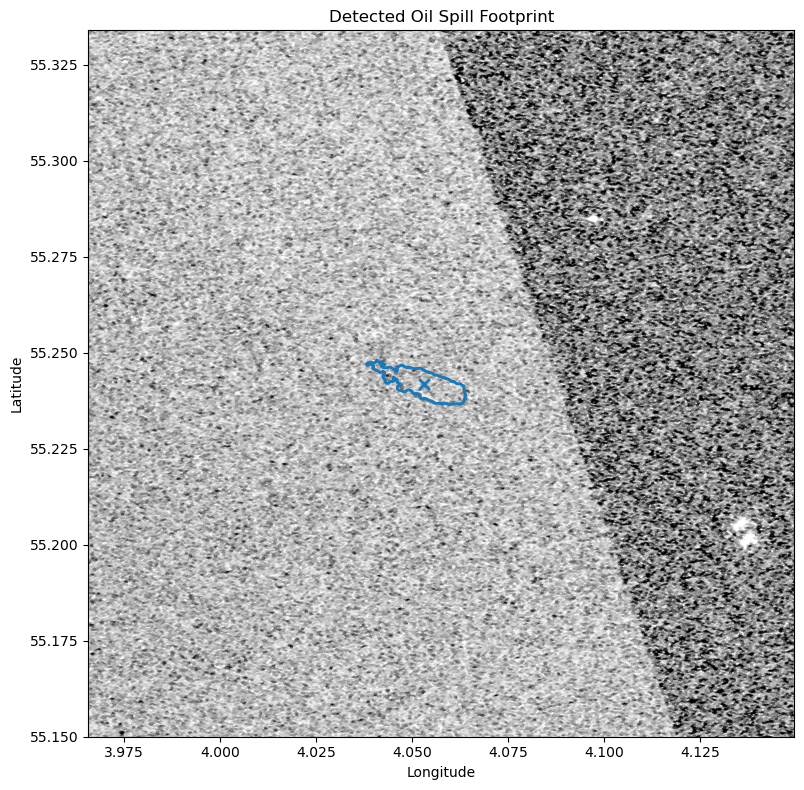

In [16]:
# Cell 16: Visualize detected spill polygon

polygon_xy = np.array(
    geographic_polygon
)

fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(
    processed_image[0],
    cmap="gray",
    extent=[
        sample_bounds.left,
        sample_bounds.right,
        sample_bounds.bottom,
        sample_bounds.top
    ],
    origin="upper"
)

ax.plot(
    polygon_xy[:, 0],
    polygon_xy[:, 1],
    linewidth=2
)

ax.scatter(
    longitude,
    latitude,
    s=60,
    marker="x",
    linewidths=2
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Detected Oil Spill Footprint")

plt.tight_layout()
plt.show()

In [17]:
# Cell 17: Create geographic spill polygon

from shapely.geometry import Polygon

spill_polygon = Polygon(
    geographic_polygon
)

print("Polygon created successfully.")
print("Valid:", spill_polygon.is_valid)
print("Geometry type:", spill_polygon.geom_type)
print("Vertices:", len(geographic_polygon))
print("Bounds:", spill_polygon.bounds)

Polygon created successfully.
Valid: True
Geometry type: Polygon
Vertices: 442
Bounds: (4.038202904283672, 55.236542790153656, 4.063984552937902, 55.247951394261975)


In [18]:
# Cell 18: Validate and clean spill polygon

if not spill_polygon.is_valid:
    spill_polygon = spill_polygon.buffer(0)

print("Geometry type:", spill_polygon.geom_type)
print("Valid:", spill_polygon.is_valid)
print("Empty:", spill_polygon.is_empty)
print("Bounds:", spill_polygon.bounds)

Geometry type: Polygon
Valid: True
Empty: False
Bounds: (4.038202904283672, 55.236542790153656, 4.063984552937902, 55.247951394261975)


In [19]:
# Cell 19: Calculate spill area using a projected CRS

import geopandas as gpd

spill_gdf = gpd.GeoDataFrame(
    {"geometry": [spill_polygon]},
    crs="EPSG:4326"
)

# Use a metric projected CRS for accurate area calculation
spill_projected = spill_gdf.to_crs(
    spill_gdf.estimate_utm_crs()
)

spill_area_m2 = spill_projected.geometry.iloc[0].area
spill_area_km2 = spill_area_m2 / 1_000_000

print("Projected CRS:", spill_projected.crs)
print(f"Spill area: {spill_area_m2:.2f} m²")
print(f"Spill area: {spill_area_km2:.6f} km²")

Projected CRS: EPSG:32631
Spill area: 925738.66 m²
Spill area: 0.925739 km²


In [20]:
# Cell 20: Create structured spill metadata

spill_metadata = {
    "image": sample_image_path.name,
    "latitude": float(latitude),
    "longitude": float(longitude),
    "area_km2": float(spill_area_km2),
    "area_pixels": int(primary_component["area_pixels"]),
    "perimeter_pixels": float(perimeter_pixels),
    "bounding_box_pixels": {
        "width": int(w),
        "height": int(h)
    },
    "aspect_ratio": float(aspect_ratio),
    "geographic_bounds": {
        "west": float(spill_polygon.bounds[0]),
        "south": float(spill_polygon.bounds[1]),
        "east": float(spill_polygon.bounds[2]),
        "north": float(spill_polygon.bounds[3])
    },
    "prediction_threshold": float(PREDICTION_THRESHOLD)
}

for key, value in spill_metadata.items():
    print(f"{key}: {value}")

image: 00000.tif
latitude: 55.24182164229434
longitude: 4.053103837300581
area_km2: 0.9257386644219509
area_pixels: 16549
perimeter_pixels: 917.7199034690857
bounding_box_pixels: {'width': 288, 'height': 128}
aspect_ratio: 2.25
geographic_bounds: {'west': 4.038202904283672, 'south': 55.236542790153656, 'east': 4.063984552937902, 'north': 55.247951394261975}
prediction_threshold: 0.5


In [21]:
# Cell 21: Export spill footprint as GeoJSON

import json

spill_geojson = {
    "type": "Feature",
    "properties": {
        "image": sample_image_path.name,
        "latitude": float(latitude),
        "longitude": float(longitude),
        "area_km2": float(spill_area_km2),
        "area_pixels": int(primary_component["area_pixels"]),
        "perimeter_pixels": float(perimeter_pixels),
        "aspect_ratio": float(aspect_ratio),
        "prediction_threshold": float(PREDICTION_THRESHOLD)
    },
    "geometry": {
        "type": "Polygon",
        "coordinates": [
            geographic_polygon + [geographic_polygon[0]]
        ]
    }
}

geojson_path = BASE / "spill_detection_result.geojson"

with open(geojson_path, "w") as f:
    json.dump(spill_geojson, f, indent=2)

print("GeoJSON exported successfully.")
print("Path:", geojson_path)
print("File exists:", geojson_path.exists())

GeoJSON exported successfully.
Path: /Volumes/Utkash SSD/SIH26143/spill_detection_result.geojson
File exists: True


In [22]:
# Cell 22: Final Phase 2 summary

print("Phase 2 Spill Analysis Summary")
print()

print("Input image:", sample_image_path.name)
print("Image size:", f"{width} × {height} px")

print("\nDetected spill:")
print(f"  Area              : {spill_area_km2:.6f} km²")
print(f"  Area (pixels)     : {primary_component['area_pixels']} px")
print(f"  Perimeter         : {perimeter_pixels:.2f} px")
print(f"  Bounding box      : {w} × {h} px")
print(f"  Aspect ratio      : {aspect_ratio:.2f}")

print("\nLocation:")
print(f"  Latitude          : {latitude:.6f}")
print(f"  Longitude         : {longitude:.6f}")

print("\nGeometry:")
print(f"  Polygon valid     : {spill_polygon.is_valid}")
print(f"  Polygon vertices  : {len(geographic_polygon)}")

print("\nOutput:")
print(f"  GeoJSON           : {geojson_path}")
print(f"  GeoJSON exists    : {geojson_path.exists()}")

print("\nPhase 2 status: COMPLETE")

Phase 2 Spill Analysis Summary

Input image: 00000.tif
Image size: 2048 × 2048 px

Detected spill:
  Area              : 0.925739 km²
  Area (pixels)     : 16549 px
  Perimeter         : 917.72 px
  Bounding box      : 288 × 128 px
  Aspect ratio      : 2.25

Location:
  Latitude          : 55.241822
  Longitude         : 4.053104

Geometry:
  Polygon valid     : True
  Polygon vertices  : 442

Output:
  GeoJSON           : /Volumes/Utkash SSD/SIH26143/spill_detection_result.geojson
  GeoJSON exists    : True

Phase 2 status: COMPLETE
